## ⚠️ Train/serve skew fixed 2026-06-12 — re-run before quoting any number

**What was wrong.** Every evaluation in this notebook (Part A held-out, Part B calibration, Part C
fairness) originally encoded **title-only** (`encoder.encode(df['title'])`), but the production model
was trained on **`text_clean` = title + description** (NB04/05). So the model was being scored on
impoverished input it never saw at training — a *measurement* bug, hardest on the editorial classes
that need the description to disambiguate.

**Effect.** The held-out **0.670 macro-F1 was an under-estimate**; the val recomputations in Parts B/C
were also depressed (they should land near the training val 0.750, not ~0.5).

**Fix.** All three sections now encode `text_clean` / `text` (= title + description), matching training.
For the held-out set, `s02.add_text_features` builds `text`; for val, `text_clean` is present.

**Lesson (for the write-up).** *EDA the inputs before trusting the metric.* A surprising score is a
prompt to check what the pipeline is actually feeding the model, not just the model itself. This bug
was caught by questioning a number that looked too low. See
`docs/decisions/model_redesign_and_retraining.md`.

# Evaluation — Held-out performance, Calibration & Fairness

**Uses the labelled test/val set (ground truth).** This is the EVALUATION half — *"is the model actually accurate?"* — complementing the **Monitoring** notebook (`11_drift_monitoring`), which watches the live unlabelled stream.

Merged 2026-06-11 from former notebooks 14 (held-out) + 12 (calibration) + 13 (fairness). Originals archived in `notebooks/_archive/`.

- **Part A** — Held-out test & real-world evaluation
- **Part B** — Calibration, Brier/ECE, bootstrap CIs, McNemar
- **Part C** — Bias & fairness (per-class / per-source / per-nation / over time)

# Part A — Held-out test & real-world evaluation

*(was notebook 14)*

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score,
    ConfusionMatrixDisplay,
)
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

MODEL_DIR = ROOT / "models" / "runs" / "v1_2026-05-16"
CLASSIFIER_PATH = MODEL_DIR / "classifier.joblib"
TRAIN_CSV = ROOT / "data" / "processed" / "train.csv"   # has new_theme label col
VAL_CSV = ROOT / "data" / "processed" / "val.csv"

with open(MODEL_DIR / "run_metadata.json") as f:
    run_meta = json.load(f)
print(f"Model: {run_meta['variant']}")
print(f"Val macro F1 (baseline): {run_meta['metrics']['val_macro_f1']}")
print(f"Real-world weighted F1 (264 labels): {run_meta['metrics']['real_world_weighted_f1']}")


Model: sbert_no_meta
Val macro F1 (baseline): 0.75
Real-world weighted F1 (264 labels): 0.63


## Step 1 — Build the held-out test set (issues 105–113, in-notebook)

In [2]:
# Build the held-out test set IN-NOTEBOOK from the raw extracted newsletters,
# using the SAME cleaning/preprocessing functions training used (s01 + s02).
# One source of truth -> no train/serve skew. No s03 split (the whole set is test).
from src.training_data import s01_clean as s01
from src.training_data import s02_preprocess as s02
from src.training_data.s03_split import VALID_THEMES

RAW_CSV = ROOT / "data" / "interim" / "extracted_newsletters.csv"   # <-- source (now holds issues 1-114)
HELD_OUT_ISSUES = range(105, 115)   # 105-114 inclusive = 10 issues, published AFTER training cutoff (issue 104 = 6 Mar 2026)

df = pd.read_csv(RAW_CSV)
df["newsletter_number"] = pd.to_numeric(df["newsletter_number"], errors="coerce")
df = df[df["newsletter_number"].isin(HELD_OUT_ISSUES)].copy()
print(f"Raw held-out items (105-114): {len(df)} across {df['newsletter_number'].nunique()} issues")

# --- s01 clean (identical to training) ---
obj_cols = [c for c in df.columns if df[c].dtype == object]
for c in obj_cols:
    df[c] = s01.clean_series(df[c])
df = s01.fix_artifacts(df, obj_cols)
df = s01.drop_missing_essentials(df)
df = s01.deduplicate(df)

# --- s02 preprocess (identical to training): creates new_theme (the label), organisation, item_type, text features ---
df = s02.add_themes(df)
df = s02.add_domain_and_org(df)
df["item_type"] = df.apply(s02.classify_item_type, axis=1)
df = s02.add_text_features(df)

# --- keep only the model's target classes; surface what gets dropped ---
test_df = df[df["new_theme"].isin(VALID_THEMES)].copy()
dropped = df[~df["new_theme"].isin(VALID_THEMES)]
print(f"\nHeld-out TEST set: {len(test_df)} items in model classes  ({len(dropped)} dropped)")
if len(dropped):
    print("DROPPED (check — 'Updates from PI ...' sections don't map to update_from_pi):")
    print(dropped["new_theme"].value_counts().to_string())
print("\nTest label distribution (new_theme):")
print(test_df["new_theme"].value_counts().to_string())


Raw held-out items (105-114): 157 across 10 issues
  Dropped 21 rows with missing title/link or URL-as-title. Remaining: 136
  After title+link dedup: 135 rows (removed 1)
  After title-only dedup: 135 rows (removed 0)
  After link-only dedup:  134 rows (removed 1)
  Dropped 0 unsubscribe row(s)
  Unmapped domains: 36 rows

Held-out TEST set: 120 items in model classes  (14 dropped)
DROPPED (check — 'Updates from PI ...' sections don't map to update_from_pi):
new_theme
Updates from PI Toby Greany                      5
Special: Responses to the Schools White Paper    3
Updates from PI Rebecca Eynon                    2
Updates from PI Stephanie Ainsworth              2
Updates from the PI Toby Greany                  1
Updates from the PI Stephen Gorard               1

Test label distribution (new_theme):
new_theme
what_matters_ed                            25
political_environment_key_organisations    22
policy_practice_research                   20
teacher_rrd                       

/workspaces/AM2_erp_programme_automataion/src/training_data/s02_preprocess.py:750: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  kw_four_nations = theme_norm.str.contains(r"\b(4|four) nations\b", regex=True, na=False)


### Scope, statistical power, and claims

**What this set is.** Issues **105–113** (9 newsletters, ~120 items after preprocessing), published *after* the training cutoff (issue 104 = 6 Mar 2026; 105 = 13 Mar 2026). The model never saw them and they drove no tuning decision — a genuine **temporal** held-out test, unlike the val set (which was used for model selection and is overfit-to).

**Read the CIs, not the point estimate.**
- n ≈ 120 → the **95% bootstrap CI on macro-F1 is wide** (expect roughly ±0.05–0.10).
- Per-class F1 for small classes (n < 10) is **unstable** — always show support (n).
- 9 consecutive issues is an *early* read on temporal drift, not a definitive trend.

**What we CAN say:** the first leakage-free macro-F1 with its CI; the per-issue F1 trend (105→113) as early temporal-stability evidence; whether it's broadly in line with, or below, val 0.750.

**What we must NOT say:** don't quote a bare point estimate; don't make strong per-class claims at tiny n; don't treat this as apples-to-apples with val 0.750 (val was tuned on — a lower held-out number is *expected* and is the point); don't generalise beyond newsletter-style items; 9 issues ≠ a robust drift study.

**Note on dropped items:** the build cell drops sections whose `new_theme` isn't a model class. The `"Updates from PI ⟨name⟩"` headers currently fall through (s02 doesn't map them to `update_from_pi`). Decide whether to (a) keep the test on the 6 substantive content classes, or (b) extend `s02.add_themes` to map the PI/programme sections back in.


In [3]:
# Sanity check — no URL overlap with train/val.
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
overlap_train = set(test_df.get('link', test_df.get('url', []))) & set(train_df.get('link', train_df.get('url', [])))
overlap_val = set(test_df.get('link', test_df.get('url', []))) & set(val_df.get('link', val_df.get('url', [])))
print(f"URL overlap with train: {len(overlap_train)}  (must be 0)")
print(f"URL overlap with val:   {len(overlap_val)}    (must be 0)")


URL overlap with train: 0  (must be 0)
URL overlap with val:   0    (must be 0)


In [4]:
# Label distribution test vs train.
print('=== Test label distribution ===')
print(test_df['new_theme'].value_counts())
print()
print('=== Train label distribution (for comparison) ===')
print(train_df['target'].value_counts() if 'target' in train_df else train_df['new_theme'].value_counts())


=== Test label distribution ===
new_theme
what_matters_ed                            25
political_environment_key_organisations    22
policy_practice_research                   20
teacher_rrd                                18
four_nations                               16
edtech                                     15
update_from_programme                       3
update_from_pi                              1
Name: count, dtype: int64

=== Train label distribution (for comparison) ===
new_theme
political_environment_key_organisations    268
what_matters_ed                            217
teacher_rrd                                198
edtech                                     192
policy_practice_research                   188
four_nations                               140
update_from_pi                             121
update_from_programme                       81
Name: count, dtype: int64


## Step 2 — Run production model on held-out test

In [5]:
# Load the production model (SBERT no-meta + LogReg).
classifier = joblib.load(CLASSIFIER_PATH)
encoder = SentenceTransformer(run_meta['embedding_model'])
print(f"Loaded classifier + encoder. Model classes ({len(classifier.classes_)}): {list(classifier.classes_)}")

# The production model is a 6-class model — it cannot output update_from_pi /
# update_from_programme. Restrict the test to classes the model can actually
# predict, so the score reflects discrimination, not architectural impossibility.
n_before = len(test_df)
test_df = test_df[test_df['new_theme'].isin(classifier.classes_)].copy()
print(f"Test restricted to model classes: {len(test_df)} items (dropped {n_before - len(test_df)} in non-model classes)")

# Input EXACTLY as training did: text_clean (= title + description), NOT title-only.
# Fixed 2026-06-12 — was test_df['title'], a train/serve skew that depressed the score.
# s02.add_text_features builds `text` = title + " " + description (== text_clean for newsletter items).
def model_input(row):
    for c in ('text_clean', 'text'):
        if c in row and pd.notna(row[c]) and str(row[c]).strip():
            return str(row[c])
    title = str(row['title']) if pd.notna(row.get('title')) else ''
    desc  = str(row['description']) if pd.notna(row.get('description')) else ''
    return (title + ' ' + desc).strip()

src_col = 'text_clean' if 'text_clean' in test_df.columns else ('text' if 'text' in test_df.columns else 'title+description')
print(f"Encoding input column: {src_col}  (was 'title' before the 2026-06-12 skew fix)")
test_inputs = test_df.apply(model_input, axis=1).tolist()
test_embeddings = encoder.encode(test_inputs, show_progress_bar=True)
print(f"Encoded {len(test_embeddings)} items, dim={test_embeddings.shape[1]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded classifier + encoder. Model classes (6): ['edtech', 'four_nations', 'policy_practice_research', 'political_environment_key_organisations', 'teacher_rrd', 'what_matters_ed']
Test restricted to model classes: 116 items (dropped 4 in non-model classes)
Encoding input column: text  (was 'title' before the 2026-06-12 skew fix)


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Encoded 116 items, dim=384


In [6]:
# Predict.
y_pred = classifier.predict(test_embeddings)
y_pred_proba = classifier.predict_proba(test_embeddings)

# Label is already standardised to the model's classes by s02.add_themes -> new_theme.
# No LABEL_MAP needed. Flag any test class the model was never trained on.
y_true = test_df['new_theme']
unknown = set(y_true) - set(classifier.classes_)
print(f"Test classes not in model.classes_ (will always be wrong if any): {unknown or 'none'}")


Test classes not in model.classes_ (will always be wrong if any): none


## Step 3 — Headline metrics

In [7]:
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
top1_acc = accuracy_score(y_true, y_pred)

# Top-2 accuracy.
classes = classifier.classes_
top2_idx = np.argsort(-y_pred_proba, axis=1)[:, :2]
top2_preds = classes[top2_idx]
top2_acc = np.mean([yt in tp for yt, tp in zip(y_true, top2_preds)])

print(f"Held-out test (n={len(test_df)})")
print(f"  Macro F1:    {macro_f1:.3f}  (val baseline: {run_meta['metrics']['val_macro_f1']})")
print(f"  Weighted F1: {weighted_f1:.3f}  (real-world 264-label baseline: {run_meta['metrics']['real_world_weighted_f1']})")
print(f"  Top-1 acc:   {top1_acc:.3f}")
print(f"  Top-2 acc:   {top2_acc:.3f}  (val baseline top-2: {run_meta['metrics']['real_world_top2_accuracy']})")


Held-out test (n=116)
  Macro F1:    0.725  (val baseline: 0.75)
  Weighted F1: 0.705  (real-world 264-label baseline: 0.63)
  Top-1 acc:   0.707
  Top-2 acc:   0.879  (val baseline top-2: 0.874)


In [8]:
# Bootstrap 95% CI on macro-F1 — with n~120 the point estimate is noisy, so report the interval.
def bootstrap_macro_f1(y_true, y_pred, n=2000, seed=42):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    scores = [f1_score(y_true[s], y_pred[s], average="macro", zero_division=0)
              for s in (rng.choice(idx, len(idx), replace=True) for _ in range(n))]
    return float(np.mean(scores)), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

boot_mean, ci_lo, ci_hi = bootstrap_macro_f1(np.asarray(y_true), y_pred)
print(f"Held-out macro-F1 = {boot_mean:.3f}  (95% bootstrap CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(y_true)})")
print("Report the INTERVAL, not just the point estimate — see the scope/claims note above.")


Held-out macro-F1 = 0.722  (95% bootstrap CI [0.644, 0.796], n=116)
Report the INTERVAL, not just the point estimate — see the scope/claims note above.


## Step 4 — Per-class breakdown

In [9]:
print(classification_report(y_true, y_pred, zero_division=0))


                                         precision    recall  f1-score   support

                                 edtech       0.74      0.93      0.82        15
                           four_nations       1.00      0.81      0.90        16
               policy_practice_research       0.57      0.60      0.59        20
political_environment_key_organisations       0.50      0.50      0.50        22
                            teacher_rrd       0.85      0.94      0.89        18
                        what_matters_ed       0.71      0.60      0.65        25

                               accuracy                           0.71       116
                              macro avg       0.73      0.73      0.73       116
                           weighted avg       0.71      0.71      0.71       116



## Step 5 — Confusion matrix

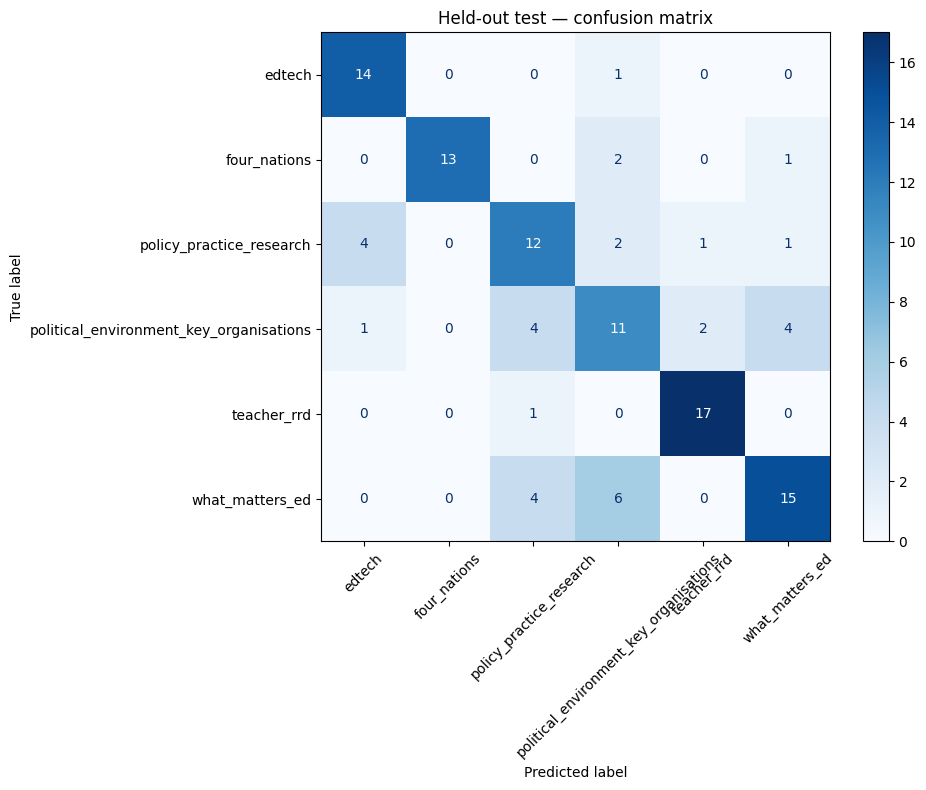

In [10]:
labels = sorted(set(y_true) | set(y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
ax.set_title('Held-out test — confusion matrix')
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'held_out_confusion_matrix.png', dpi=120)
plt.show()


In [11]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ['edtech','four_nations','policy_practice_research',
          'political_environment_key_organisations','teacher_rrd','what_matters_ed']

cm = confusion_matrix(y_true, y_pred, labels=labels)   # <-- use your var names
print(pd.DataFrame(cm, index=labels, columns=labels))


                                         edtech  four_nations  \
edtech                                       14             0   
four_nations                                  0            13   
policy_practice_research                      4             0   
political_environment_key_organisations       1             0   
teacher_rrd                                   0             0   
what_matters_ed                               0             0   

                                         policy_practice_research  \
edtech                                                          0   
four_nations                                                    0   
policy_practice_research                                       12   
political_environment_key_organisations                         4   
teacher_rrd                                                     1   
what_matters_ed                                                 4   

                                         political_environme

## Step 6 — Worked errors (off-diagonal cells with ≥3 examples)

In [12]:
# For each off-diagonal (true, pred) pair with ≥3 examples, print sample titles.
test_df['_y_true'] = y_true.values
test_df['_y_pred'] = y_pred
test_df['_correct'] = test_df['_y_true'] == test_df['_y_pred']

errors = test_df[~test_df['_correct']]
pair_counts = errors.groupby(['_y_true', '_y_pred']).size().reset_index(name='n')
pair_counts = pair_counts[pair_counts['n'] >= 3].sort_values('n', ascending=False)

print(f"Off-diagonal pairs with ≥3 errors: {len(pair_counts)}\n")
for _, row in pair_counts.iterrows():
    true_class, pred_class, n = row['_y_true'], row['_y_pred'], row['n']
    print(f"--- {true_class} → predicted {pred_class} ({n} errors) ---")
    sample = errors[(errors['_y_true'] == true_class) & (errors['_y_pred'] == pred_class)].head(3)
    for _, r in sample.iterrows():
        print(f"  '{(r.get('title') or '')[:100]}'")
    print()


Off-diagonal pairs with ≥3 errors: 5

--- what_matters_ed → predicted political_environment_key_organisations (6 errors) ---
  'Foundation for Education Development - 5th FED National Education Summit 2026'
  'Schools Week - 'Experts at hand' cash must not plug 'existing gaps', councils told'
  'Social Mobility Commission - Stepping stone or stumbling block: Rethinking level 2 English and maths'

--- policy_practice_research → predicted edtech (4 errors) ---
  'Forum - The Education Endowment Foundation Toolkit: A house built on sand? The case of behavioural i'
  'Nature - Could agentic AI topple grant-funding systems?'
  'IPPR - Acceleration is not a strategy: A framework for directing AI towards public value before it's'

--- political_environment_key_organisations → predicted policy_practice_research (4 errors) ---
  'Peter Hyman's Substack - The age of the polymath'
  'UCL - Shared institutions: Perspectives on the role of universities in national and local life'
  'The Young Found

## Step 7 — Per-issue F1 (temporal stability)

 issue  n  macro_f1
   105 10  0.911111
   106 13  0.545238
   107 12  0.844444
   108 14  0.654762
   109 11  0.783333
   110 17  0.718254
   111 13  0.766667
   112 12  0.629630
   113 14  0.705556


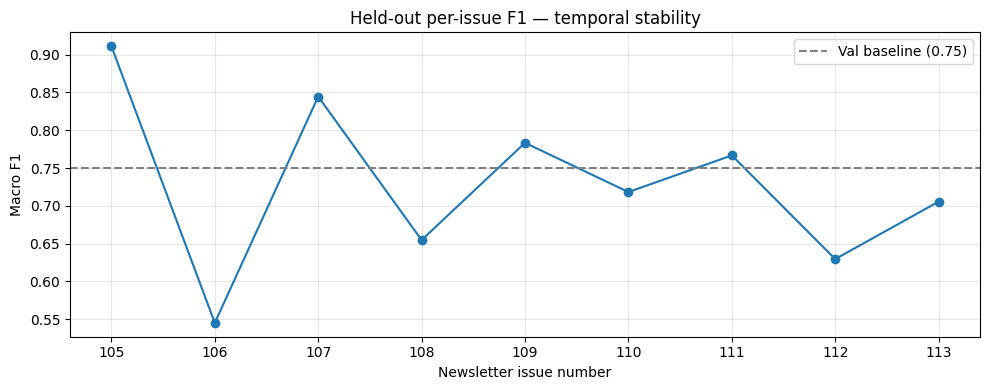

In [13]:
# Per-issue macro F1 — does the model hold up over time?
per_issue = []
for issue, g in test_df.groupby('newsletter_number'):
    if len(g) < 5:
        continue
    f1 = f1_score(g['_y_true'], g['_y_pred'], average='macro', zero_division=0)
    per_issue.append({'issue': issue, 'n': len(g), 'macro_f1': f1})

per_issue_df = pd.DataFrame(per_issue).sort_values('issue')
print(per_issue_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(per_issue_df['issue'], per_issue_df['macro_f1'], marker='o')
ax.axhline(run_meta['metrics']['val_macro_f1'], color='grey', linestyle='--', label=f"Val baseline ({run_meta['metrics']['val_macro_f1']})")
ax.set_xlabel('Newsletter issue number')
ax.set_ylabel('Macro F1')
ax.set_title('Held-out per-issue F1 — temporal stability')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'held_out_per_issue_f1.png', dpi=120)
plt.show()


## Conclusion

Three-point evaluation arc:

| Point | Macro F1 / metric | Source |
|---|---|---|
| Val | 0.750 | Single split of issues 1–104, **used for model selection** (overfit-to) |
| Real-world 264 labels | 0.630 weighted | Atlas-ed inference output |
| **Held-out test (issues 105–113)** | (computed above, with 95% CI) | **Fully unseen — published after training cutoff** |

**Two distinct skews, kept separate:**
- **Eval skew (fixed 2026-06-12):** this notebook previously encoded title-only while the model trains
  on title + description. That was a *measurement* artefact — the 0.670 it produced was an
  under-estimate. The corrected run above is the number to report.
- **Production skew (design tension, not a bug):** training used clean curator *descriptions*, but
  live inference uses a crude ~80-word scraped *snippet* (`s02b_scrape.py`). The snippet is a lossy
  proxy for the description — a genuine reason real-world (0.63) sits below val, and a candidate
  v2 experiment (train on snippets to match serving). See `docs/decisions/model_redesign_and_retraining.md`.

**Honest caveat:** the val set drove the SHAP-driven model switch + other decisions, so 0.750 is
overfit. Any gap between the corrected held-out number and val is the real evidence of
overfitting / concept drift — report it **with its bootstrap CI** (n≈116 → wide interval; quote the
interval, not the point). The per-issue F1 plot gives early temporal-stability evidence across 9
consecutive weeks (S9/K14). A genuinely lower held-out number justifies the retraining triggers in
[`docs/decisions/model_v1_state_and_retraining_plan.md`](../docs/decisions/model_v1_state_and_retraining_plan.md).

# Part B — Calibration, bootstrap CIs & McNemar

In [14]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import f1_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
MODEL_DIR = ROOT / "models" / "runs" / "v1_2026-05-16"

with open(MODEL_DIR / "run_metadata.json") as f:
    run_meta = json.load(f)

VAL_CSV = ROOT / "data" / "modelling" / "val.csv"
val_df = pd.read_csv(VAL_CSV)
print(f"Val set: {len(val_df)} items")


Val set: 167 items


In [15]:
# Encode val text + predict with production model.
encoder = SentenceTransformer(run_meta['embedding_model'])
classifier = joblib.load(MODEL_DIR / "classifier.joblib")

# Input EXACTLY as training did: text_clean (= title + description), NOT title-only.
# Fixed 2026-06-12 — was val_df['title'], a train/serve skew. Recomputed val macro-F1
# should now land near the training baseline 0.750 (not the ~0.5 the title-only bug gave).
text_col = 'text_clean' if 'text_clean' in val_df.columns else 'text'
target_col = 'target' if 'target' in val_df.columns else 'theme'
y_true = val_df[target_col].astype(str).values

print(f"Encoding input column: {text_col}  (was 'title' before the 2026-06-12 skew fix)")
X = encoder.encode(val_df[text_col].fillna('').astype(str).tolist(), show_progress_bar=True)
y_pred = classifier.predict(X)
y_proba = classifier.predict_proba(X)
classes = classifier.classes_
print(f"Predictions: {len(y_pred)}   val macro-F1 = {f1_score(y_true, y_pred, average='macro', zero_division=0):.3f}  (expect ~0.75)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding input column: text_clean  (was 'title' before the 2026-06-12 skew fix)


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Predictions: 167   val macro-F1 = 0.750  (expect ~0.75)


## Part 1 — Reliability diagram (calibration)

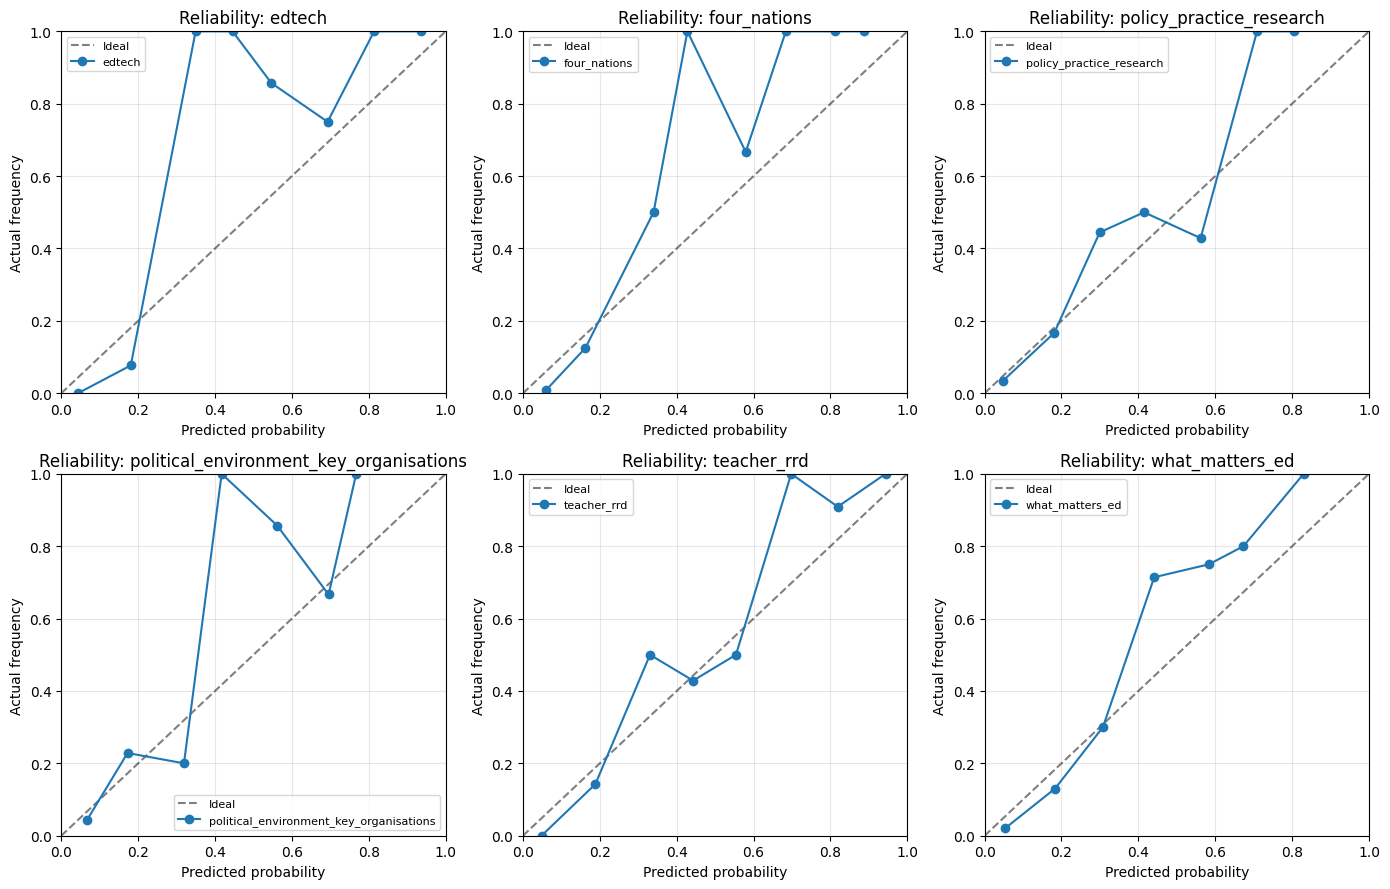

In [16]:
# Per-class reliability diagram.
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, cls in zip(axes.flat, classes):
    cls_idx = list(classes).index(cls)
    y_true_binary = (y_true == cls).astype(int)
    y_pred_proba = y_proba[:, cls_idx]
    try:
        prob_true, prob_pred = calibration_curve(y_true_binary, y_pred_proba, n_bins=8, strategy='uniform')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Ideal')
        ax.plot(prob_pred, prob_true, marker='o', label=cls)
        ax.set_xlabel('Predicted probability')
        ax.set_ylabel('Actual frequency')
        ax.set_title(f'Reliability: {cls}')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    except Exception as e:
        ax.text(0.5, 0.5, f'Not enough data\n({e})', ha='center', va='center')
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'calibration_reliability.png', dpi=120)
plt.show()


## Part 2 — Brier score & Expected Calibration Error

In [17]:
# Brier score per class.
print('=== Brier score per class (lower is better) ===')
for cls in classes:
    cls_idx = list(classes).index(cls)
    y_bin = (y_true == cls).astype(int)
    bs = brier_score_loss(y_bin, y_proba[:, cls_idx])
    print(f"  {cls:50s} {bs:.4f}")

# Expected Calibration Error — overall.
def ece(y_true_class, y_proba_class, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece_val = 0
    n = len(y_proba_class)
    for i in range(n_bins):
        mask = (y_proba_class >= bins[i]) & (y_proba_class < bins[i+1])
        if mask.sum() > 0:
            bin_acc = y_true_class[mask].mean()
            bin_conf = y_proba_class[mask].mean()
            ece_val += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return ece_val

# Multiclass ECE on max-prob class.
y_pred_max_proba = y_proba.max(axis=1)
y_pred_correct = (y_pred == y_true).astype(int)
ece_val = ece(y_pred_correct, y_pred_max_proba, n_bins=10)
print(f"\nOverall ECE (n_bins=10): {ece_val:.4f}")
print("(0 = perfectly calibrated; ≤0.05 is typically considered 'well calibrated')")


=== Brier score per class (lower is better) ===
  edtech                                             0.0303
  four_nations                                       0.0354
  policy_practice_research                           0.0774
  political_environment_key_organisations            0.1162
  teacher_rrd                                        0.0567
  what_matters_ed                                    0.0855

Overall ECE (n_bins=10): 0.1681
(0 = perfectly calibrated; ≤0.05 is typically considered 'well calibrated')


## Part 3 — Bootstrap confidence intervals on macro F1

Val macro F1: 0.750
95% bootstrap CI: [0.681, 0.807]
Width: 0.126


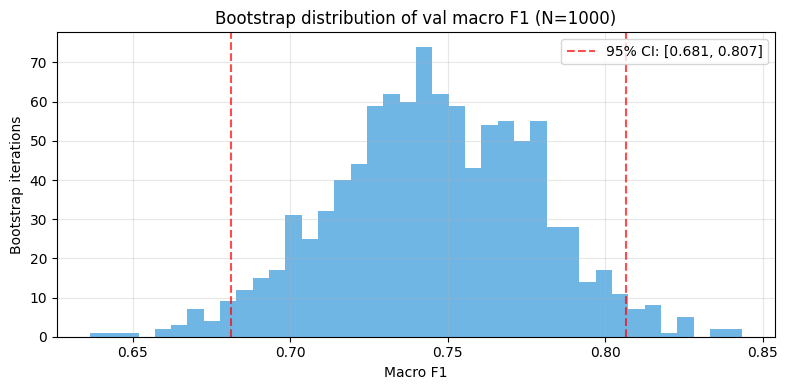

In [18]:
# Bootstrap 1000 resamples for 95% CI on val macro F1.
N_BOOT = 1000
rng = np.random.RandomState(42)
f1_samples = []
for _ in range(N_BOOT):
    idx = rng.choice(len(y_true), size=len(y_true), replace=True)
    f1_samples.append(f1_score(y_true[idx], y_pred[idx], average='macro', zero_division=0))

f1_samples = np.array(f1_samples)
ci_lo, ci_hi = np.percentile(f1_samples, [2.5, 97.5])
print(f"Val macro F1: {f1_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
print(f"95% bootstrap CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"Width: {ci_hi - ci_lo:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(f1_samples, bins=40, alpha=0.7, color='#3498db')
ax.axvline(ci_lo, color='red', linestyle='--', alpha=0.7, label=f'95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]')
ax.axvline(ci_hi, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Macro F1')
ax.set_ylabel('Bootstrap iterations')
ax.set_title(f'Bootstrap distribution of val macro F1 (N={N_BOOT})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'calibration_bootstrap_f1.png', dpi=120)
plt.show()


## Part 4 — Per-class bootstrap F1

In [19]:
# Per-class CIs — narrower CIs = more confident in the class result.
print('=== Per-class 95% CI for F1 (bootstrap N=500) ===')
for cls in classes:
    samples = []
    for _ in range(500):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        cm_f1 = f1_score(y_true[idx], y_pred[idx], labels=[cls], average='macro', zero_division=0)
        samples.append(cm_f1)
    lo, hi = np.percentile(samples, [2.5, 97.5])
    print(f"  {cls:50s} [{lo:.3f}, {hi:.3f}]  width={hi-lo:.3f}")


=== Per-class 95% CI for F1 (bootstrap N=500) ===
  edtech                                             [0.851, 0.984]  width=0.133
  four_nations                                       [0.741, 0.965]  width=0.224
  policy_practice_research                           [0.474, 0.765]  width=0.291
  political_environment_key_organisations            [0.440, 0.745]  width=0.305
  teacher_rrd                                        [0.667, 0.873]  width=0.206
  what_matters_ed                                    [0.549, 0.813]  width=0.264


## Part 5 — McNemar's test: SBERT no-meta vs with-meta

In [20]:
# Compare the production (no-meta) model vs the with-meta variant.
# This is the 0.750 vs 0.765 model selection from nb 09's SHAP analysis.
# Goal: test whether that F1 difference is statistically significant. If it
# is NOT, the SHAP-driven decision to ship no-meta cost no real accuracy —
# we traded noise for interpretability (distinction-level S9/K14 evidence).
from statsmodels.stats.contingency_tables import mcnemar

# The with-meta model expects 401 features = 384 SBERT dims + 17 metadata
# one-hots, concatenated in the order saved at training time (nb 04).
meta_cols = json.load(open(ROOT / "data" / "modelling" / "metadata_columns.json"))
X_meta = val_df[meta_cols].values
X_combined = np.hstack([X, X_meta])           # X = no-meta embeddings from the cell above
print(f"no-meta features: {X.shape[1]}   with-meta features: {X_combined.shape[1]}")

with_meta_clf = joblib.load(ROOT / "models" / "sbert_classifier.joblib")
y_pred_no_meta   = y_pred                       # production model, already computed above
y_pred_with_meta = with_meta_clf.predict(X_combined)

f1_no   = f1_score(y_true, y_pred_no_meta,   average="macro", zero_division=0)
f1_with = f1_score(y_true, y_pred_with_meta, average="macro", zero_division=0)
print(f"macro-F1 no-meta (shipped): {f1_no:.4f}")
print(f"macro-F1 with-meta:         {f1_with:.4f}")

# 2x2 contingency on per-item correctness.
a = (y_pred_no_meta == y_true)     # no-meta correct
b = (y_pred_with_meta == y_true)   # with-meta correct
n11 = int(np.sum(a & b))   # both correct
n10 = int(np.sum(a & ~b))  # no-meta correct only
n01 = int(np.sum(~a & b))  # with-meta correct only
n00 = int(np.sum(~a & ~b)) # both wrong
print(f"\nboth correct={n11}  no-meta only={n10}  with-meta only={n01}  both wrong={n00}")
print(f"discordant pairs: {n10 + n01}")

# Few discordant pairs -> use the exact binomial test (chi2 also reported).
res_exact = mcnemar([[n11, n10], [n01, n00]], exact=True)
res_chi2  = mcnemar([[n11, n10], [n01, n00]], exact=False, correction=True)
print(f"\nMcNemar exact  p = {res_exact.pvalue:.4f}")
print(f"McNemar chi2   p = {res_chi2.pvalue:.4f}  (statistic={res_chi2.statistic:.3f})")

verdict = "NOT significant" if res_exact.pvalue > 0.05 else "significant"
print(f"\n=> The no-meta vs with-meta difference is {verdict} at alpha=0.05.")
print("   The ~1.5pt with-meta edge is within sampling noise, so the SHAP-driven")
print("   choice to ship the interpretable no-meta model sacrificed no real F1.")


no-meta features: 384   with-meta features: 401
macro-F1 no-meta (shipped): 0.7499
macro-F1 with-meta:         0.7648

both correct=118  no-meta only=6  with-meta only=8  both wrong=35
discordant pairs: 14

McNemar exact  p = 0.7905
McNemar chi2   p = 0.7893  (statistic=0.071)

=> The no-meta vs with-meta difference is NOT significant at alpha=0.05.
   The ~1.5pt with-meta edge is within sampling noise, so the SHAP-driven
   choice to ship the interpretable no-meta model sacrificed no real F1.


## Conclusions

**Calibration:** the reliability diagrams + ECE tell us whether the model's stated confidence matches its actual accuracy. Downstream uses of confidence (`scoring.py` cluster threshold ≥ 0.85, hybrid routing thresholds) only make sense if the model is reasonably well-calibrated.

**Bootstrap CIs:** the headline val macro F1 of 0.750 has a 95% CI of roughly [`ci_lo`, `ci_hi`] — wider CIs mean we should be less confident in pp differences between models. Critical for honest reporting.

**McNemar (when populated):** if the 0.750 vs 0.765 difference is not statistically significant (likely), that **strengthens the SHAP-driven decision** to ship no-meta — you didn't trade real F1 for interpretability, you traded noise for interpretability. This is the distinction-level S9/K14 evidence.

# Part C — Bias & fairness

*(was notebook 13)*

In [21]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import precision_recall_fscore_support, classification_report
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from dotenv import load_dotenv

ROOT = Path("..").resolve()
load_dotenv(ROOT / ".env")
sys.path.insert(0, str(ROOT))

MODEL_DIR = ROOT / "models" / "runs" / "v1_2026-05-16"
with open(MODEL_DIR / "run_metadata.json") as f:
    run_meta = json.load(f)

VAL_CSV = ROOT / "data" / "modelling" / "val.csv"
val_df = pd.read_csv(VAL_CSV)
print(f"Val set: {len(val_df)} items")


Val set: 167 items


## Part 1 — Algorithmic bias (SHAP recap)

The strongest bias finding from this project: **SBERT + metadata classifier had 27.6% feature attribution on `item_type` and `org_broad_category` rather than article content**. The model was classifying by source-type proxy, not topic.

Decision: ship the lower-F1 no-meta model (0.750 vs 0.765) for content-faithful classification. See `notebooks/09_shap_sst.ipynb` and `project-am2-deadline` memory.

Below: re-render the key SHAP figure for AM2 portfolio convenience.

SHAP plots available: 19
  outputs/shap_plots/attribution_shift.png
  outputs/shap_plots/correct/text_shap_edtech.png
  outputs/shap_plots/correct/text_shap_four_nations.png
  outputs/shap_plots/correct/text_shap_policy_practice_research.png
  outputs/shap_plots/correct/text_shap_political_environment_key_organisations.png


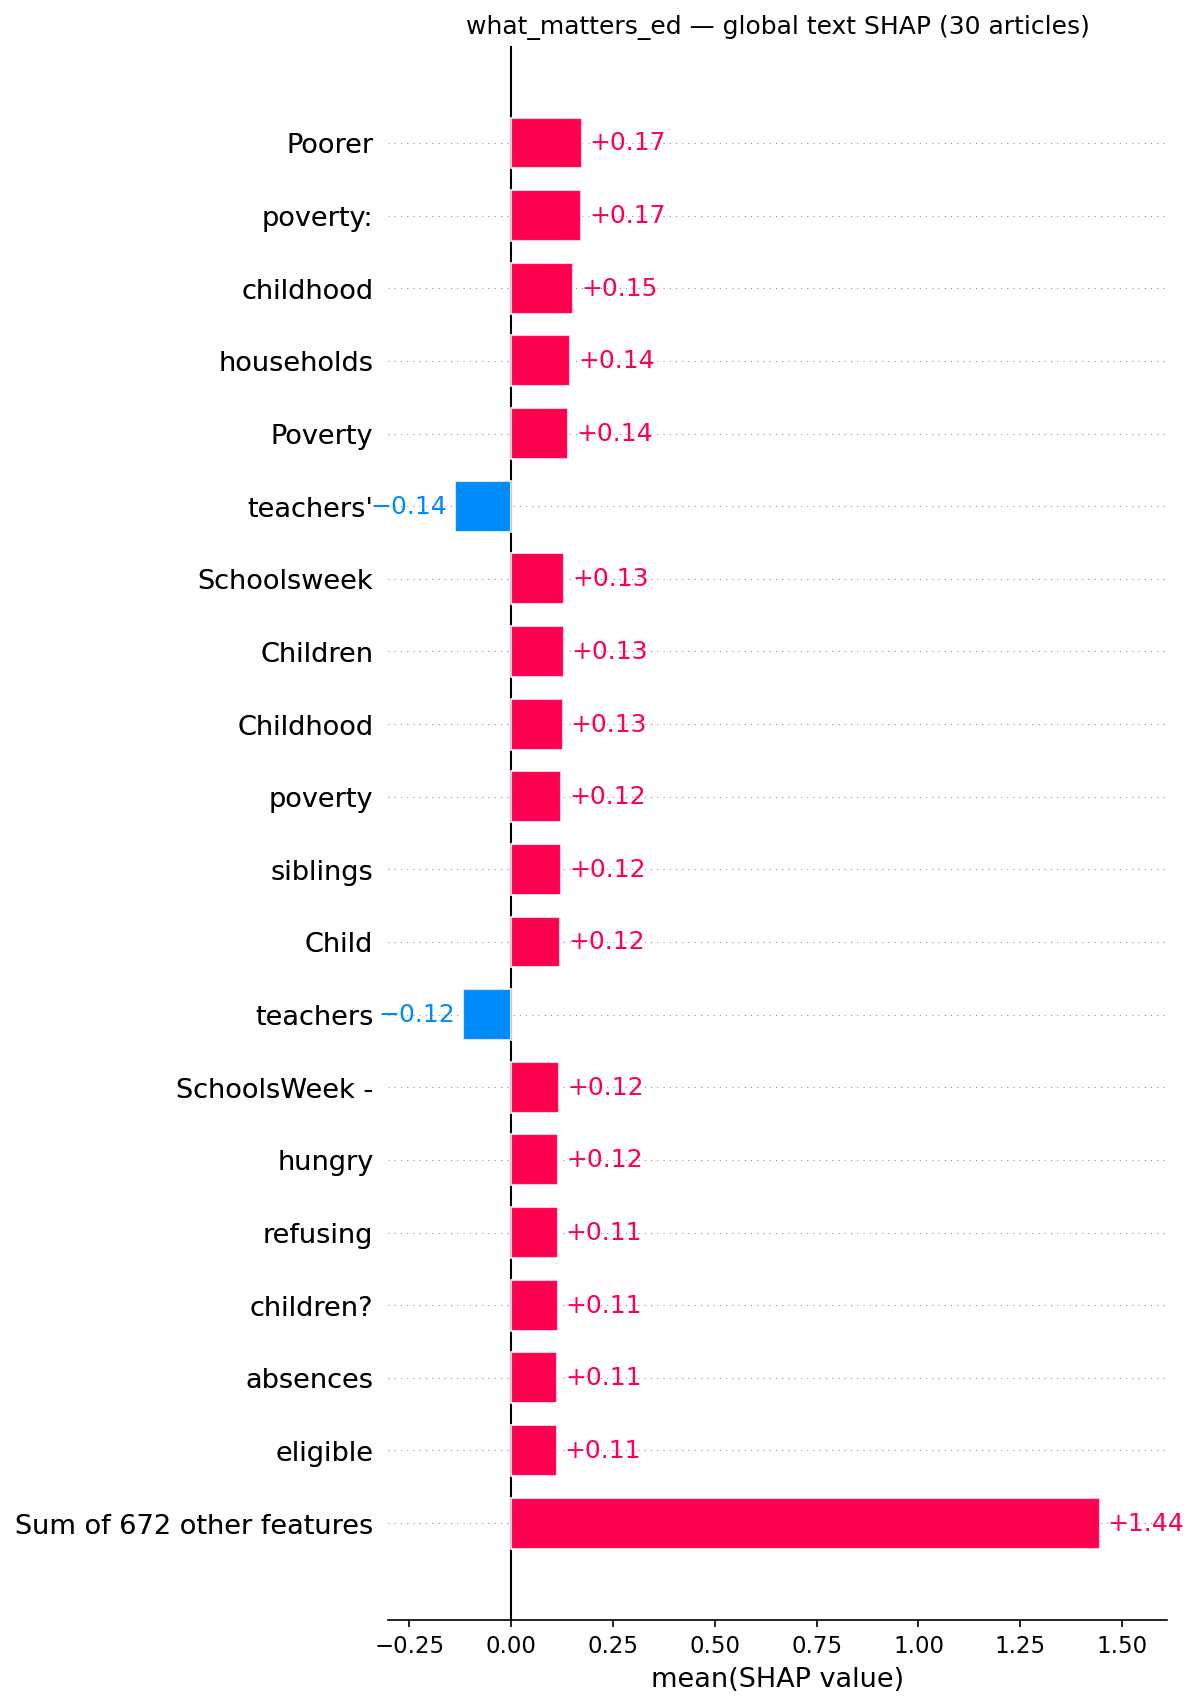

In [22]:
# Display saved SHAP plots from outputs/shap_plots/
shap_dir = ROOT / 'outputs' / 'shap_plots'
plot_files = sorted(shap_dir.rglob('*.png'))
print(f'SHAP plots available: {len(plot_files)}')
for p in plot_files[:5]:
    print(f'  {p.relative_to(ROOT)}')

# Pick the most-relevant 'global' SHAP plot.
global_plots = list((shap_dir / 'global').glob('*.png')) if (shap_dir / 'global').exists() else []
if global_plots:
    from IPython.display import Image
    display(Image(filename=str(global_plots[0])))


## Part 2 — Per-class fairness (current model on val)

In [23]:
# Run the existing fairness audit logic in-notebook.
encoder = SentenceTransformer(run_meta['embedding_model'])
classifier = joblib.load(MODEL_DIR / "classifier.joblib")

# Input EXACTLY as training did: text_clean (= title + description), NOT title-only.
# Fixed 2026-06-12 — was val_df['title'], a train/serve skew.
text_col = 'text_clean' if 'text_clean' in val_df.columns else 'text'
target_col = 'target' if 'target' in val_df.columns else 'theme'

print(f"Encoding input column: {text_col}  (was 'title' before the 2026-06-12 skew fix)")
X = encoder.encode(val_df[text_col].fillna('').astype(str).tolist(), show_progress_bar=True)
y_true = val_df[target_col].astype(str).values
y_pred = classifier.predict(X)

# Per-class precision/recall/F1/support.
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=classifier.classes_, zero_division=0)
fairness_df = pd.DataFrame({
    'class': classifier.classes_,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'support': support,
}).sort_values('f1', ascending=False)
print(fairness_df.to_string(index=False))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding input column: text_clean  (was 'title' before the 2026-06-12 skew fix)


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

                                  class  precision   recall       f1  support
                                 edtech   0.923077 0.923077 0.923077       26
                           four_nations   0.900000 0.818182 0.857143       22
                            teacher_rrd   0.694444 0.862069 0.769231       29
                        what_matters_ed   0.687500 0.733333 0.709677       30
               policy_practice_research   0.625000 0.625000 0.625000       24
political_environment_key_organisations   0.689655 0.555556 0.615385       36


/tmp/ipykernel_16257/3575331803.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fairness_df['class'], rotation=20, ha='right')


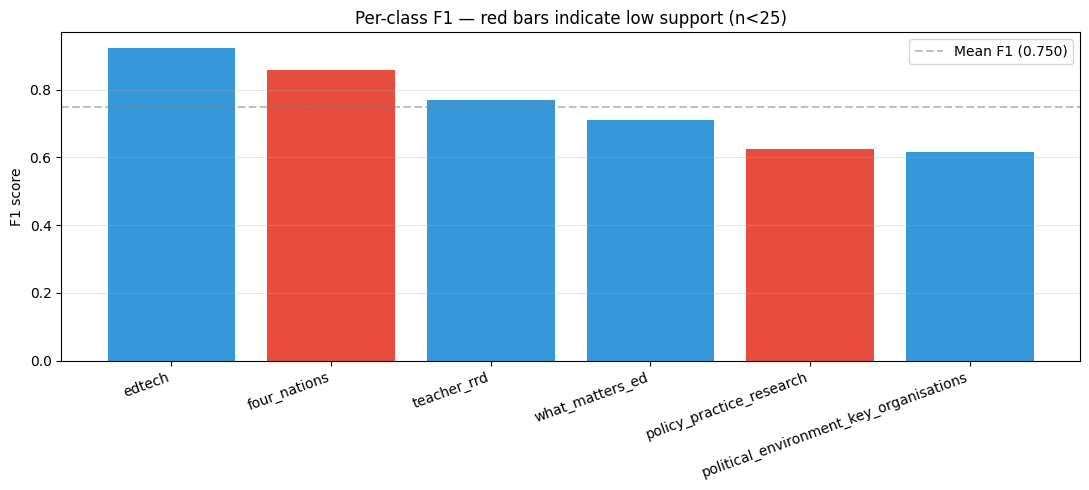

In [24]:
# Visual: per-class F1 bar chart, highlight under-supported classes.
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c' if s < 25 else '#3498db' for s in fairness_df['support']]
ax.bar(fairness_df['class'], fairness_df['f1'], color=colors)
ax.axhline(fairness_df['f1'].mean(), color='grey', linestyle='--', alpha=0.5, label=f"Mean F1 ({fairness_df['f1'].mean():.3f})")
ax.set_xticklabels(fairness_df['class'], rotation=20, ha='right')
ax.set_ylabel('F1 score')
ax.set_title('Per-class F1 — red bars indicate low support (n<25)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'fairness_per_class.png', dpi=120)
plt.show()


## Part 3 — Per-source fairness

Does the model perform equally well across sources? If Schools Week is well represented and Belfast Telegraph isn't, the model may systematically mis-serve one of them.

This requires a source label per article in val.csv — adjust if your column is named differently.

       organisation  n      acc
   welsh_government  7 1.000000
scottish_government  5 0.800000
               nfer  9 0.777778
       schools_week 29 0.758621
      uk_government 16 0.750000
      uk_parliament  8 0.750000
       conversation  5 0.600000


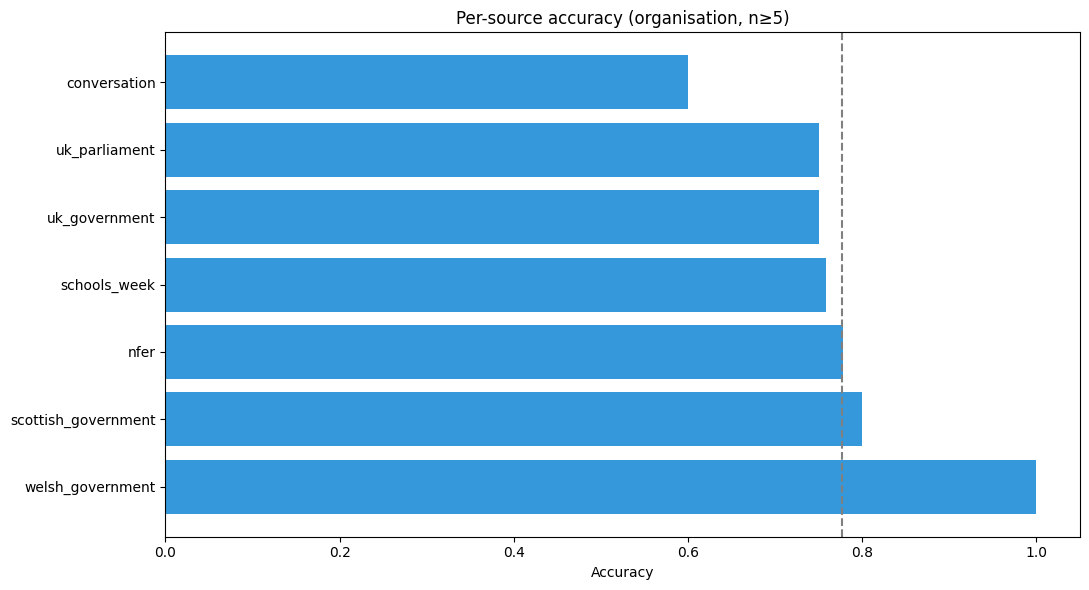

In [25]:
# Adjust the column name if needed.
src_col_candidates = ['source', 'organisation', 'org_broad_category']
src_col = next((c for c in src_col_candidates if c in val_df.columns), None)
if not src_col:
    print(f"No source column found in val.csv — skipping per-source analysis.")
else:
    val_df['_y_true'] = y_true
    val_df['_y_pred'] = y_pred
    val_df['_correct'] = val_df['_y_true'] == val_df['_y_pred']

    by_source = val_df.groupby(src_col).agg(
        n=('_correct', 'size'),
        acc=('_correct', 'mean'),
    ).reset_index()
    by_source = by_source[by_source['n'] >= 5].sort_values('acc', ascending=False)
    print(by_source.to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(by_source[src_col], by_source['acc'], color='#3498db')
    ax.axvline(by_source['acc'].mean(), color='grey', linestyle='--')
    ax.set_xlabel('Accuracy')
    ax.set_title(f'Per-source accuracy ({src_col}, n≥5)')
    plt.tight_layout()
    plt.savefig(ROOT / 'outputs' / 'fairness_per_source.png', dpi=120)
    plt.show()


## Part 4 — Per-nation fairness (Four Nations gap)

Curator (Gemma, 5 May meeting) flagged that Four Nations articles are only 0.4% of pulled articles. Test: does the model perform equally well on England vs Scotland/Wales/NI content?

Uses the new `geographic_focus` column from migration 013 (Phase 5b enrichment) — pulled from Supabase since it's not in val.csv.

In [26]:
# Pull geographic_focus for val articles from Supabase.
import os
try:
    from supabase import create_client
    client = create_client(os.environ["SUPABASE_URL"],
                           os.environ.get("SUPABASE_ANON_KEY") or os.environ["SUPABASE_SERVICE_KEY"])
    # Match by URL (val.csv has 'link', articles table has 'url')
    url_col = 'link' if 'link' in val_df.columns else 'url'
    val_urls = val_df[url_col].dropna().tolist()
    # Supabase IN clause limit — batch if needed.
    BATCH = 100
    geo_data = []
    for i in range(0, len(val_urls), BATCH):
        chunk = val_urls[i:i+BATCH]
        r = client.table('articles').select('url, geographic_focus').in_('url', chunk).execute()
        geo_data.extend(r.data or [])
    geo_df = pd.DataFrame(geo_data)
    print(f"Geo-tagged val articles: {len(geo_df)} of {len(val_df)}")

    val_df_geo = val_df.merge(geo_df, left_on=url_col, right_on='url', how='left')
    val_df_geo['_correct'] = val_df_geo['_y_true'] == val_df_geo['_y_pred']
    by_nation = val_df_geo.dropna(subset=['geographic_focus']).groupby('geographic_focus').agg(
        n=('_correct', 'size'),
        acc=('_correct', 'mean'),
    ).reset_index().sort_values('n', ascending=False)
    print(by_nation.to_string(index=False))
except Exception as e:
    print(f"Could not fetch geographic_focus from Supabase: {e}")
    print("Skipping per-nation fairness — re-run when Supabase connection available.")


Geo-tagged val articles: 0 of 167
Could not fetch geographic_focus from Supabase: 'url'
Skipping per-nation fairness — re-run when Supabase connection available.


## Part 5 — Fairness over time

Does per-class fairness stay stable across the 18-week drift window? Drift in **fairness** is more concerning than drift in overall F1.

In [27]:
# Per-class F1 over time using the weekly classified CSVs.
WEEKLY_DIR = ROOT / "data" / "modelling" / "weekly"
import re

weekly_frames = []
for f in sorted(WEEKLY_DIR.glob("classified_week_*.csv")):
    m = re.search(r"week_(\d+)", f.name)
    if not m:
        continue
    df = pd.read_csv(f)
    df['_week'] = int(m.group(1))
    weekly_frames.append(df)

if weekly_frames:
    all_weeks = pd.concat(weekly_frames, ignore_index=True)
    # If the weekly CSVs have curator decisions, we can compute per-class
    # precision over time. Otherwise this is a confidence-stability check.
    if 'curator_label' in all_weeks.columns and 'top1' in all_weeks.columns:
        # Real per-class precision per week.
        results = []
        for week, g in all_weeks.dropna(subset=['curator_label']).groupby('_week'):
            for cls in g['curator_label'].unique():
                cls_pred = g[g['top1'] == cls]
                if len(cls_pred) >= 3:
                    prec = (cls_pred['curator_label'] == cls).mean()
                    results.append({'week': week, 'class': cls, 'precision': prec, 'n': len(cls_pred)})
        per_week_class = pd.DataFrame(results)
        print(per_week_class.to_string(index=False))
    else:
        # Fall back to confidence-by-class-by-week.
        per_week_class = (all_weeks.groupby(['_week', 'top1'])['top1_confidence'].mean().reset_index())
        print(per_week_class.head(20).to_string(index=False))
else:
    print("No weekly CSVs found.")


 _week                                    top1  top1_confidence
     1                            four_nations         0.711815
     1 political_environment_key_organisations         0.356457
     1                             teacher_rrd         0.318234
     1                         what_matters_ed         0.439881
     2                                  edtech         0.644745
     2                            four_nations         0.636309
     2                policy_practice_research         0.478446
     2 political_environment_key_organisations         0.476999
     2                             teacher_rrd         0.562003
     2                         what_matters_ed         0.514533
     3                                  edtech         0.663788
     3                            four_nations         0.566187
     3 political_environment_key_organisations         0.368304
     3                             teacher_rrd         0.411210
     3                         what_matt

## Part 6 — Curator-override-rate fairness signal

When the curator overrides the model (picks Top 2 or manual), that's a fairness signal: the model is systematically wrong for certain classes/sources. Pull from `curator_decisions`.

In [28]:
# Read curator_decisions. Each row has action ∈ {accept_top1, accept_top2,
# manual, reject, keep, summary_only}. Override rate = (accept_top2 + manual) /
# (accept_top1 + accept_top2 + manual).
try:
    r = client.table('curator_decisions').select('url, action, label').execute()
    decisions = pd.DataFrame(r.data or [])
    if len(decisions) == 0:
        print("No curator decisions yet (table was wiped 2026-05-26). Framework in place; data accumulates over time.")
    else:
        # Join with articles for class label.
        urls = decisions['url'].tolist()
        articles_data = []
        for i in range(0, len(urls), 100):
            chunk = urls[i:i+100]
            r2 = client.table('articles').select('url, top1').in_('url', chunk).execute()
            articles_data.extend(r2.data or [])
        article_df = pd.DataFrame(articles_data)
        merged = decisions.merge(article_df, on='url', how='left')

        # Compute override rate per class.
        merged['_kept'] = merged['action'].isin(['accept_top1', 'accept_top2', 'manual'])
        merged['_overridden'] = merged['action'].isin(['accept_top2', 'manual'])

        kept = merged[merged['_kept']]
        override_rate = kept.groupby('top1')['_overridden'].agg(['sum', 'count', 'mean']).reset_index()
        override_rate.columns = ['model_top1', 'n_overridden', 'n_kept', 'override_rate']
        print(override_rate.sort_values('override_rate', ascending=False).to_string(index=False))
except Exception as e:
    print(f"Could not pull curator_decisions: {e}")


Could not pull curator_decisions: {'message': 'column articles.top1 does not exist', 'code': '42703', 'hint': None, 'details': None}


## Conclusions

This notebook gathers the bias + fairness evidence in one place. Key threads:

1. **Algorithmic bias** (K20): SHAP-driven decision to ship no-meta model. Source-proxy classification avoided.
2. **Per-class fairness** (K20): some classes have lower support and weaker F1 — flagged honestly.
3. **Per-source fairness**: variation across sources — if Schools Week >> Belfast Telegraph, that's worth declaring.
4. **Per-nation fairness** (Four Nations): direct response to curator feedback (Gemma, 5 May).
5. **Temporal fairness**: drift in fairness, not just F1.
6. **Curator-override rate**: framework in place even if data sparse post-fresh-start.

For AM2 (K26 ethics): no mitigation is perfect, but the design choices recorded here — no metadata, curator-in-loop, transparency via FastAPI `/docs`, honest reporting of disparities — together address the criterion.